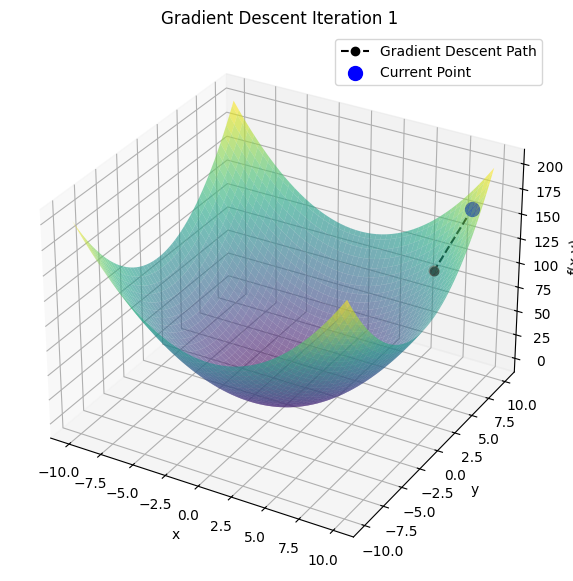

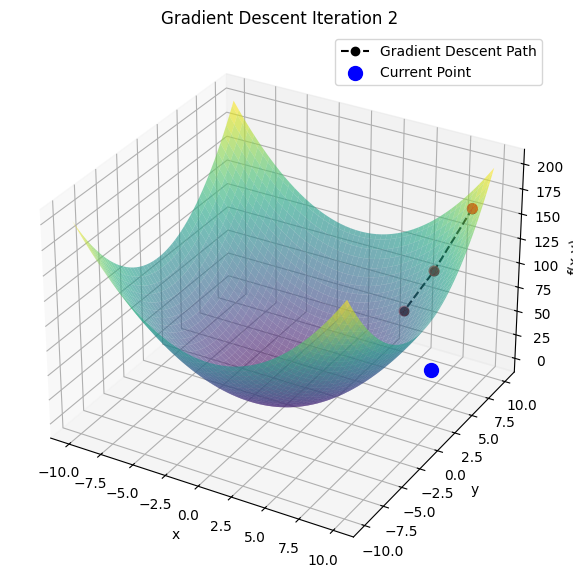

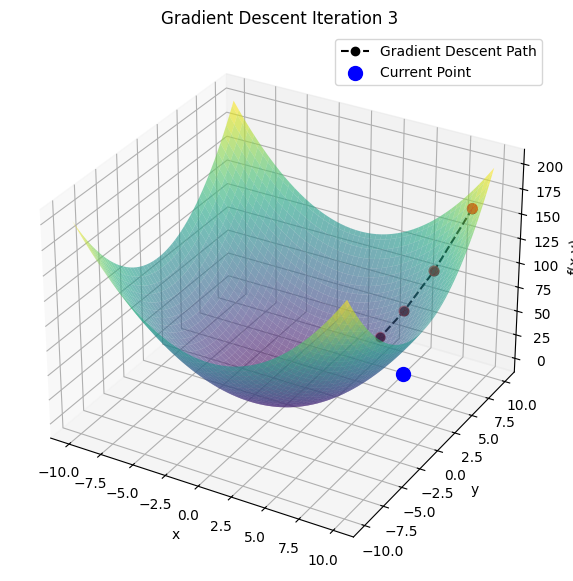

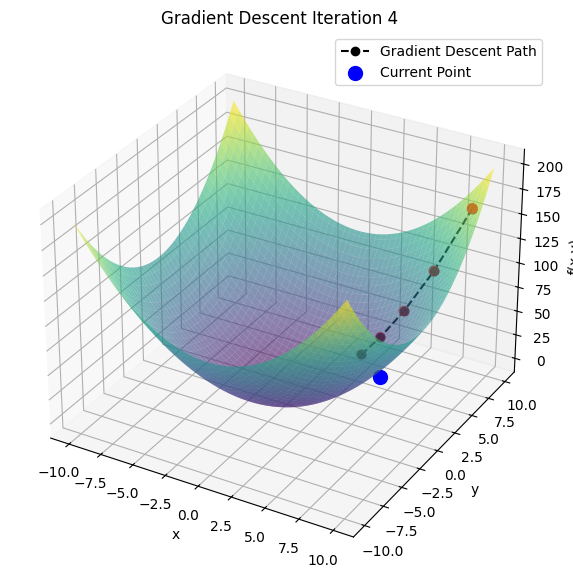

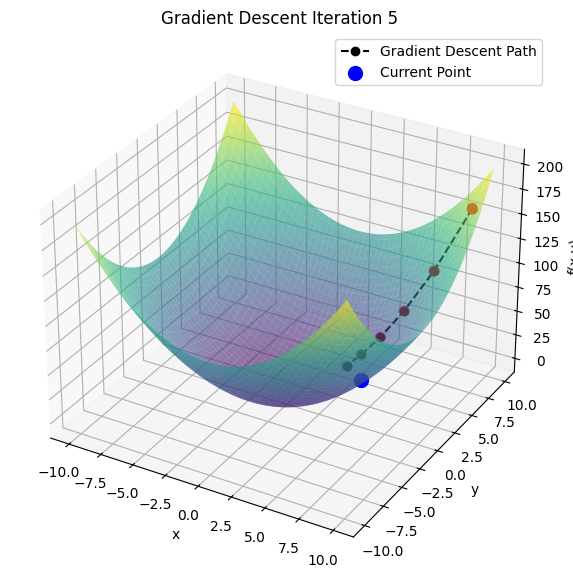

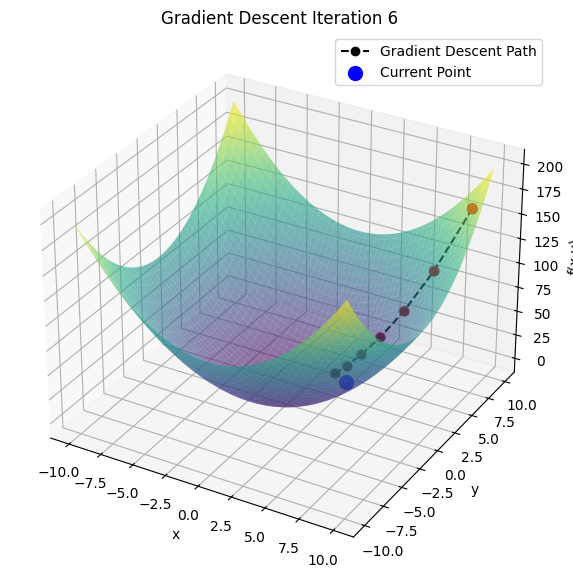

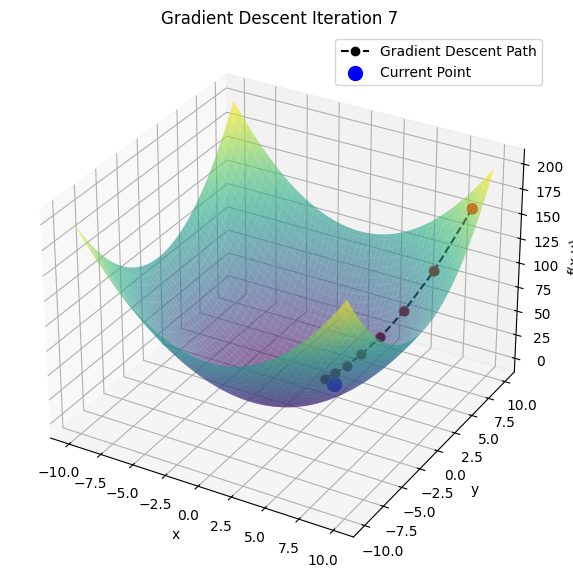

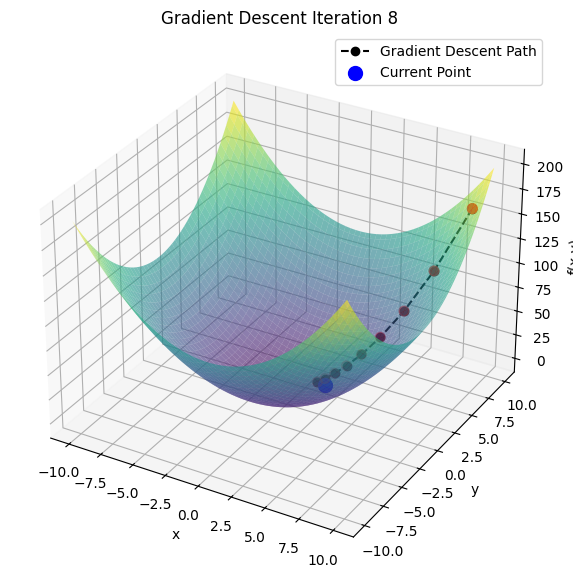

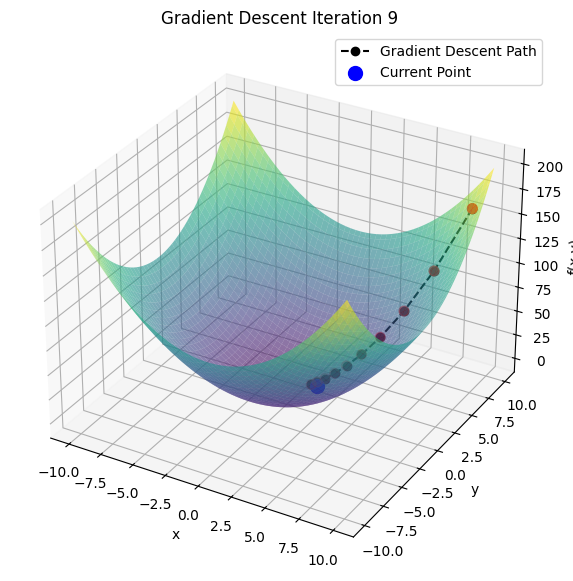

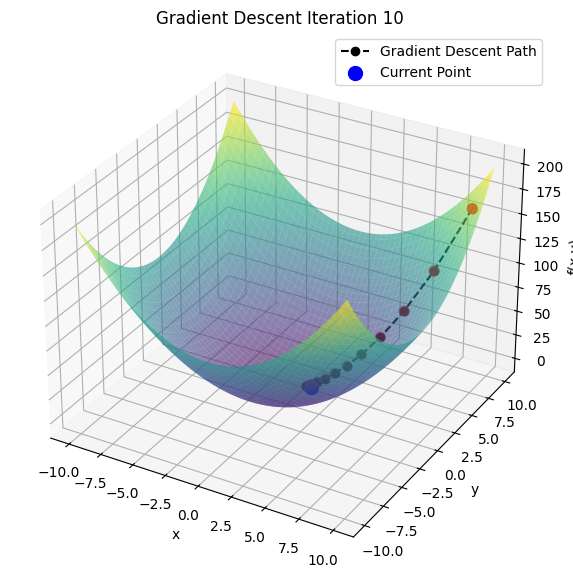

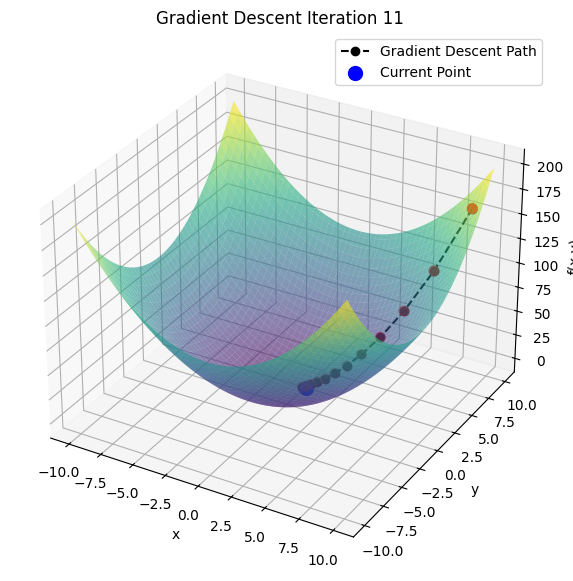

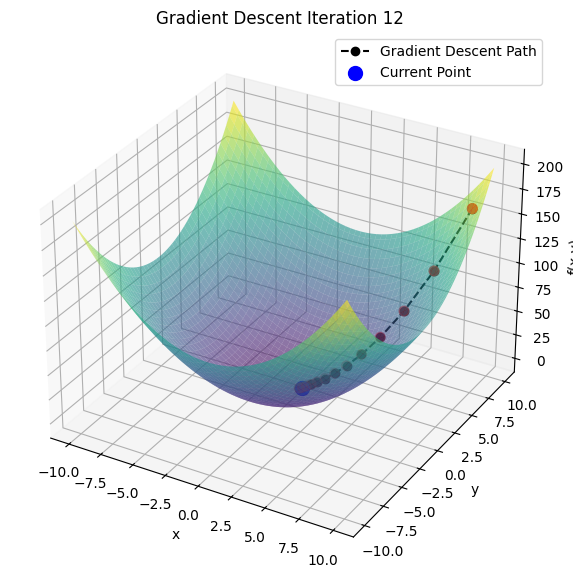

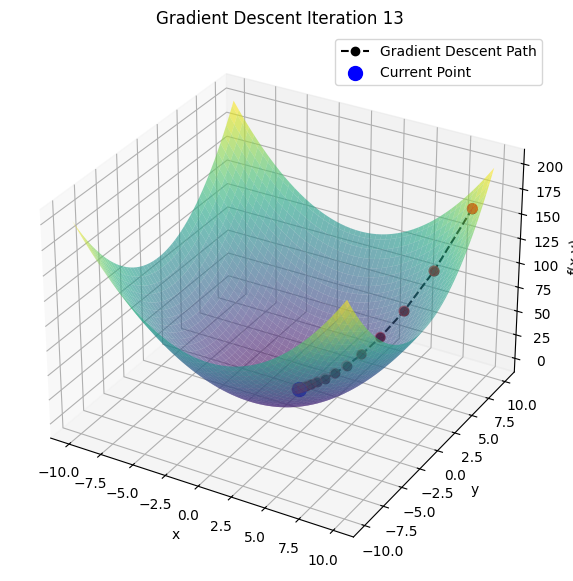

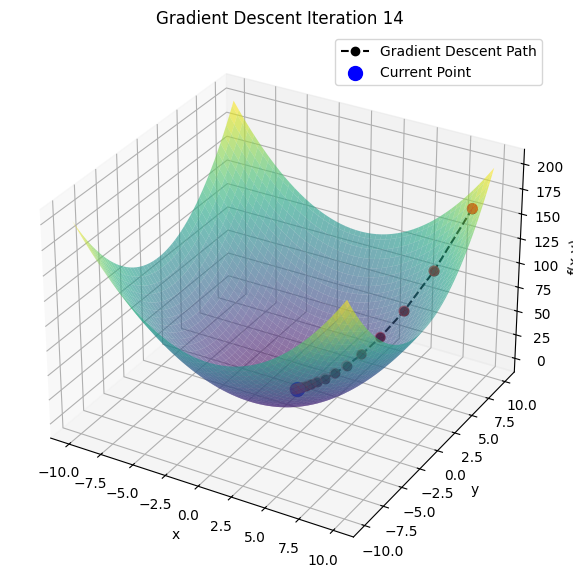

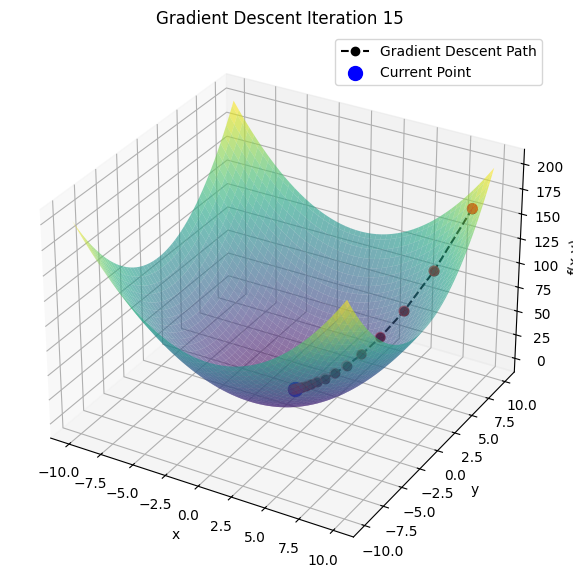

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------------
# Loss function
# -----------------------------------
def f(x, y):
    return x**2 + y**2

# -----------------------------------
# Gradient of the function
# ∇f = [df/dx, df/dy]
# -----------------------------------
def df(x, y):
    return np.array([2*x, 2*y])

# -----------------------------------
# Gradient Descent Parameters
# -----------------------------------
x_start = 9
y_start = 9

learning_rate = 0.1
n_iterations = 15

# -----------------------------------
# Store optimization path
# -----------------------------------
x_steps = [x_start]
y_steps = [y_start]
z_steps = [f(x_start, y_start)]

# -----------------------------------
# Create surface mesh
# -----------------------------------
x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)

X, Y = np.meshgrid(x, y)

Z = f(X, Y)

# -----------------------------------
# Gradient Descent Loop
# -----------------------------------
for i in range(n_iterations):

    # Current point
    current_x = x_steps[-1]
    current_y = y_steps[-1]

    # Compute gradient
    gradient = df(current_x, current_y)

    # Gradient descent update
    next_x = current_x - learning_rate * gradient[0]
    next_y = current_y - learning_rate * gradient[1]

    # Compute new function value
    next_z = f(next_x, next_y)

    # Store new step
    x_steps.append(next_x)
    y_steps.append(next_y)
    z_steps.append(next_z)

    # -----------------------------------
    # Create NEW figure every iteration
    # -----------------------------------
    fig = plt.figure(figsize=(10, 7))

    ax = fig.add_subplot(111, projection='3d')

    # -----------------------------------
    # Plot loss surface
    # -----------------------------------
    ax.plot_surface(
        X,
        Y,
        Z,
        alpha=0.6,
        cmap='viridis'
    )

    # -----------------------------------
    # Plot optimization path
    # -----------------------------------
    ax.scatter(
        x_steps,
        y_steps,
        z_steps,
        color='red',
        s=50
    )

    ax.plot(
        x_steps,
        y_steps,
        z_steps,
        linestyle='--',
        marker='o',
        color='black',
        label='Gradient Descent Path'
    )

    # -----------------------------------
    # Highlight current point
    # -----------------------------------
    ax.scatter(
        current_x,
        current_y,
        current_z if i > 0 else z_steps[0],
        color='blue',
        s=100,
        label='Current Point'
    )

    # -----------------------------------
    # Labels and title
    # -----------------------------------
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('f(x,y)')

    ax.set_title(f'Gradient Descent Iteration {i+1}')

    ax.legend()

    plt.show()